# Abacus Particle-Shell Residual Validation

This notebook tests whether Abacus total particle HEALPix shells can add the missing low-mass and diffuse contribution to the pasted high-mass halo maps.

The target is not just prettier maps. The target is that `gkappa_cmb`, `gkappa_wl`, and `gtau` cross-spectra move toward the matching GODMAX theory curves on large/intermediate scales while leaving the small-scale pasted halo profiles intact. kSZ is included as a map and cross-correlation diagnostic using `heal-vel-los`, but there is no current GODMAX kSZ theory curve in this workflow.

Inputs under `/mnt/ceph/users/backlight/.../lightcone_healpix/total` are read-only. Caches and plots are written only under `notebooks/xDESI/outputs/abacus_particle_shell_tests`.


In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

from pathlib import Path
import sys
import gc

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'xDESI':
    NOTEBOOK_DIR = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import abacus_pasting_helpers as aph
import abacus_particle_shell_helpers as psh

CONFIG = NOTEBOOK_DIR / 'abacus_pasting_config.yaml'
CATALOG = 'zlt0p5_logMgt14p0'
NSIDE = 1024
TOTAL_ROOT = Path('/mnt/ceph/users/backlight/AbacusBacklight_base_c9999_ph9999/lightcone_healpix/total')

# Keep the first pass cheap. Set MAX_SHELLS=None after cache files exist.
MAX_SHELLS = None
OVERWRITE_CACHE = False

# NFW/DMO selected-halo templates are the slowest part. They are cached.
RUN_NFW_TEMPLATE = True
NFW_VELOCITY_BINS = 4  # Use 4-8 for a more faithful NFW-weighted kSZ momentum template.

# Low-ell replacement scan.
TAPER_ELLS = [128, 256, 512, 768]
TRAIN_ELL_RANGE = (60, 350)

# Plot binning. Increase DELTA_ELL for smoother curves.
ELL_PLOT_MIN = 10
ELL_PLOT_MAX = 3000
DELTA_ELL = 20

# Theory recommendation from the satellite/gg diagnostics:
# use raw/power-add galaxy clustering, not the response-suppressed Pgg model.
# Set to None to use the YAML config value, or 'response' for the old comparison.
THEORY_GG_TRANSITION_MODEL = 'poweradd'
THEORY_LABEL = f'GODMAX theory (gg_transition_model={THEORY_GG_TRANSITION_MODEL or "config"})'

cfg = aph.load_config(CONFIG)
CACHE_ROOT = psh.particle_shell_cache_root(cfg, NSIDE)
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('cache root:', CACHE_ROOT)


cache root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_particle_shell_tests/nside1024


## 1. Inspect Available Shell Products

The important distinction is between velocity components and momentum. Metadata says `heal-vel-phi` is an angular velocity component, not momentum. For kSZ, this notebook uses `heal-vel-los` and count-weights it while downgrading.


In [2]:
quantity_summary = pd.DataFrame(psh.summarize_healpix_quantity_dirs(TOTAL_ROOT))
display(quantity_summary)

shell_meta_all = psh.discover_total_shells(TOTAL_ROOT, z_max_hint=0.5)
print('n shell files:', len(shell_meta_all))
print('scanned redshift coverage:', shell_meta_all[-1]['z_lo'], 'to', shell_meta_all[0]['z_hi'])

shell_meta = psh.select_shells(shell_meta_all, z_min=1.0e-4, z_max=0.5, max_shells=MAX_SHELLS)
print('selected shells:', len(shell_meta))
display(pd.DataFrame(shell_meta)[['step_id', 'z_lo', 'z_hi', 'chi_lo_hMpc', 'chi_hi_hMpc', 'nside_counts', 'nside_vel_los', 'mean_count_fine']])


,quantity_dir,n_files,data_key,map_quantity,nside,order,dtype,first_step,last_step,z_max,z_min
0,heal-counts,150,heal-counts,counts,8192,nest,uint32,Step0222-0224,Step1014-1022,3.192338,0.000135
1,heal-vel-los,150,heal-vel-los,vel-los,8192,nest,int16,Step0222-0224,Step1014-1022,3.192338,0.000135
2,heal-vel-theta,150,heal-vel-theta,vel-theta,4096,nest,int16,Step0222-0224,Step1014-1022,3.192338,0.000135
3,heal-vel-phi,150,heal-vel-phi,vel-phi,4096,nest,int16,Step0222-0224,Step1014-1022,3.192338,0.000135


n shell files: 44
scanned redshift coverage: 0.000134659018104 to 0.503574707007947
selected shells: 44


,step_id,z_lo,z_hi,chi_lo_hMpc,chi_hi_hMpc,nside_counts,nside_vel_los,mean_count_fine
0,Step0689-0695,0.488610,0.503575,1288.240019,1322.195410,8192,8192,19.908603
1,Step0696-0701,0.476326,0.488610,1260.136435,1288.240019,8192,8192,15.668643
2,Step0702-0707,0.464236,0.476326,1232.267014,1260.136435,8192,8192,14.874664
3,Step0708-0714,0.450055,0.464236,1199.319878,1232.267014,8192,8192,16.670899
4,Step0715-0721,0.437067,0.450055,1168.892807,1199.319878,8192,8192,14.559600
5,Step0722-0727,0.424893,0.437067,1140.154244,1168.892807,8192,8192,13.122702
6,Step0728-0734,0.411525,0.424893,1108.352748,1140.154244,8192,8192,13.821166
7,Step0735-0740,0.400115,0.411525,1081.006244,1108.352748,8192,8192,11.255640
8,Step0741-0747,0.386673,0.400115,1048.548262,1081.006244,8192,8192,12.656652
9,Step0748-0753,0.375617,0.386673,1021.656498,1048.548262,8192,8192,9.870732


## 2. Velocity Interpretation Check

If `vel-los` were a velocity sum, its distribution would grow strongly with count. If it is a mean velocity per occupied fine pixel, nonzero velocity should occur only where counts are nonzero and its scatter should be roughly velocity-like rather than count-like. The cache uses the latter interpretation: coarse momentum is `sum(counts * vel_los_mean)`.


In [3]:
diag_shells = [shell_meta[0], shell_meta[len(shell_meta)//2], shell_meta[-1]] if len(shell_meta) > 2 else shell_meta
vel_diag = [psh.velocity_interpretation_diagnostic(m, sample_pixels=5_000_000) for m in diag_shells]
display(pd.DataFrame(vel_diag))


,step_id,sample_pixels,count_nonzero_frac,vel_nonzero_frac,vel_nonzero_where_count_zero,vel_std_count1,vel_mean_count1,n_count1,vel_std_count2,vel_mean_count2,...,n_count4,vel_std_count8,vel_mean_count8,n_count8,vel_std_count16,vel_mean_count16,n_count16,vel_std_count32,vel_mean_count32,n_count32
0,Step0689-0695,5000000,0.997958,0.995537,0,185.996941,50.633682,44849,175.707870,51.869862,...,244886.0,174.309600,50.199975,306619.0,184.628284,49.411949,128334.0,198.755828,48.791817,27668.0
1,Step0840-0846,5000000,0.805534,0.803842,0,216.598985,41.679094,1118664,205.731632,39.094435,...,360580.0,211.269752,38.318951,89255.0,222.815936,40.538818,18986.0,232.677795,47.174210,4242.0
2,Step1014-1022,5000000,0.002563,0.002559,0,101.635636,102.737770,12428,108.898800,89.716763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Load Pasted Maps, Halo Catalog, And Theory

This notebook assumes the small-catalog pasted map already exists at `NSIDE=1024`. Generate it with `abacus_quick_paste_validation.ipynb` or the Slurm paste/combine scripts if needed.


In [4]:
map_path = aph.final_map_path(cfg, CATALOG, NSIDE)
if not map_path.exists():
    raise FileNotFoundError(f'Missing pasted map: {map_path}')

maps_pasted, galaxies, map_attrs = aph.load_maps_h5(map_path)
halo_catalog, halo_attrs = aph.load_halo_catalog(aph.catalog_path(cfg, CATALOG))
print(map_path)
print('maps:', sorted(maps_pasted))
print('galaxies:', galaxies.shape, 'halos:', len(halo_catalog['z']))

nz_info, _, _ = aph.load_xdesi_fit_lens_info(cfg)
compare_bin = 0
z_edges = np.asarray(nz_info['z_edges_bins_lens'])
z_range = tuple(z_edges[compare_bin])
z_mean = 0.5 * (z_range[0] + z_range[1])
print('comparison lens bin:', compare_bin, 'z_range:', z_range)

cls_cmb = aph.build_theory_cls(
    CONFIG,
    CATALOG,
    is_cmb_lensing=True,
    log10_mass_min=14.0,
    z_max=0.5,
    gg_transition_model=THEORY_GG_TRANSITION_MODEL,
)
cls_wl = aph.build_theory_cls(
    CONFIG,
    CATALOG,
    is_cmb_lensing=False,
    log10_mass_min=14.0,
    z_max=0.5,
    gg_transition_model=THEORY_GG_TRANSITION_MODEL,
)
print('theory gg_transition_model:', getattr(cls_cmb, 'gg_transition_model', THEORY_GG_TRANSITION_MODEL))
ell_th = np.asarray(cls_cmb.ell_array)
tau_fac = aph.tau_theory_conversion(cls_cmb.cosmo_params, z_mean)
theory = {
    'gg': np.asarray(cls_cmb.Cl_gal_gal_tot_mat[:, compare_bin, compare_bin]),
    'gy': np.asarray(cls_cmb.Cl_gal_y_tot_mat[:, compare_bin]),
    'gkappa_cmb': np.asarray(cls_cmb.Cl_gal_kappa_tot_mat[:, compare_bin, 0]),
    'gkappa_wl': np.asarray(cls_wl.Cl_gal_kappa_tot_mat[:, compare_bin, 0]),
    'gtau': np.asarray(cls_cmb.Cl_gal_tau_tot_mat[:, compare_bin]) * tau_fac,
}


/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/outputs/abacus_maps/abacus_c9999_ph9999_xdesi/abacus_pasted_maps_zlt0p5_logMgt14p0_nside1024.h5
maps: ['map_kappa_cmb', 'map_kappa_wl', 'map_ksz', 'map_rhom', 'map_rhom_dmb', 'map_rhom_dmo', 'map_tau', 'map_ymap']
galaxies: (223411, 6) halos: 140661
comparison lens bin: 0 z_range: (0.2741959798994975, 0.4268643216080403)


E0601 19:18:56.143678 1347474 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.5.82, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


theory gg_transition_model: poweradd


## 4. Downgrade And Cache Shell Maps

Each source file is read once, downgraded by summing exact NESTED child pixels, reordered to RING, and cached as HDF5. For LOS velocity the cached products are:

- `counts_1024`
- `vel_los_count_weighted_1024`
- `momentum_los_1024 = counts_1024 * vel_los_count_weighted_1024`

The conservation columns below should be close to machine precision relative to the count totals, modulo float32 output storage.


In [5]:
cache_paths = {}
cache_rows = []
for i, meta in enumerate(shell_meta, 1):
    print(f'[{i}/{len(shell_meta)}] cache {meta["step_id"]}')
    path = psh.read_or_create_downgraded_shell_cache(meta, NSIDE, CACHE_ROOT, overwrite=OVERWRITE_CACHE)
    cache_paths[meta['step_id']] = path
    _, attrs = psh.load_downgraded_shell_cache(path, NSIDE)
    cache_rows.append({
        'step_id': meta['step_id'],
        'path': str(path),
        'input_count_sum': attrs['input_count_sum'],
        'output_count_sum': attrs['output_count_sum'],
        'rel_count_error': (attrs['output_count_sum'] - attrs['input_count_sum']) / max(attrs['input_count_sum'], 1.0),
        'vel_nonzero_count_zero': attrs['vel_nonzero_count_zero_fine_pixels'],
        'runtime_sec': attrs.get('cache_runtime_sec', 0.0),
    })
cache_summary = pd.DataFrame(cache_rows)
display(cache_summary)


[1/44] cache Step0689-0695
[2/44] cache Step0696-0701
[3/44] cache Step0702-0707
[4/44] cache Step0708-0714
[5/44] cache Step0715-0721
[6/44] cache Step0722-0727
[7/44] cache Step0728-0734
[8/44] cache Step0735-0740
[9/44] cache Step0741-0747
[10/44] cache Step0748-0753
[11/44] cache Step0754-0760
[12/44] cache Step0761-0767
[13/44] cache Step0768-0774
[14/44] cache Step0775-0781
[15/44] cache Step0782-0788
[16/44] cache Step0789-0795
[17/44] cache Step0796-0802
[18/44] cache Step0803-0809
[19/44] cache Step0810-0817
[20/44] cache Step0818-0824
[21/44] cache Step0825-0831
[22/44] cache Step0832-0839
[23/44] cache Step0840-0846
[24/44] cache Step0847-0854
[25/44] cache Step0855-0861
[26/44] cache Step0862-0869
[27/44] cache Step0870-0876
[28/44] cache Step0877-0884
[29/44] cache Step0885-0892
[30/44] cache Step0893-0900
[31/44] cache Step0901-0909
[32/44] cache Step0910-0917
[33/44] cache Step0918-0926
[34/44] cache Step0927-0934
[35/44] cache Step0935-0943
[36/44] cache Step0944-0952
[

,step_id,path,input_count_sum,output_count_sum,rel_count_error,vel_nonzero_count_zero,runtime_sec
0,Step0689-0695,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.603252e+10,1.603252e+10,0.0,0,18.082516
1,Step0696-0701,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.261806e+10,1.261806e+10,0.0,0,18.460728
2,Step0702-0707,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.197866e+10,1.197866e+10,0.0,0,18.545631
3,Step0708-0714,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.342518e+10,1.342518e+10,0.0,0,17.898948
4,Step0715-0721,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.172494e+10,1.172494e+10,0.0,0,17.985533
5,Step0722-0727,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.056780e+10,1.056780e+10,0.0,0,18.672790
6,Step0728-0734,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.113027e+10,1.113027e+10,0.0,0,18.359747
7,Step0735-0740,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,9.064239e+09,9.064239e+09,0.0,0,18.406134
8,Step0741-0747,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,1.019248e+10,1.019248e+10,0.0,0,18.272724
9,Step0748-0753,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...,7.948963e+09,7.948963e+09,0.0,0,18.059031


## 5. Kernel Weights And Midpoint Error

The shell contribution is computed as an integral over shell depth in `h^-1 Mpc`. The table compares shell-averaged weights against midpoint weights; large deviations would mean the shell is too thick for midpoint weighting.


,step_id,z_mid,dchi_hMpc,kappa_cmb_avg,kappa_cmb_mid_over_avg,kappa_wl_avg,kappa_wl_mid_over_avg,tau_avg,tau_mid_over_avg
0,Step0689-0695,0.496092,33.955391,0.003021,1.001021,0.001985,1.000561,0.000051,1.000649
1,Step0696-0701,0.482468,28.103584,0.002430,1.000308,0.001619,1.000185,0.000041,1.000180
2,Step0702-0707,0.470281,27.869421,0.002346,1.000217,0.001582,1.000140,0.000040,1.000122
3,Step0708-0714,0.457145,32.947135,0.002691,1.000108,0.001840,1.000111,0.000047,1.000073
4,Step0715-0721,0.443561,30.427071,0.002407,1.000331,0.001669,1.000220,0.000042,1.000178
5,Step0722-0727,0.430980,28.738563,0.002205,1.000231,0.001548,1.000163,0.000039,1.000123
6,Step0728-0734,0.418209,31.801495,0.002364,1.000117,0.001680,1.000112,0.000043,1.000075
7,Step0735-0740,0.405820,27.346504,0.001969,1.000358,0.001417,1.000256,0.000036,1.000175
8,Step0741-0747,0.393394,32.457983,0.002261,1.000250,0.001646,1.000201,0.000042,1.000131
9,Step0748-0753,0.381145,26.891764,0.001812,1.000132,0.001335,1.000114,0.000034,1.000072


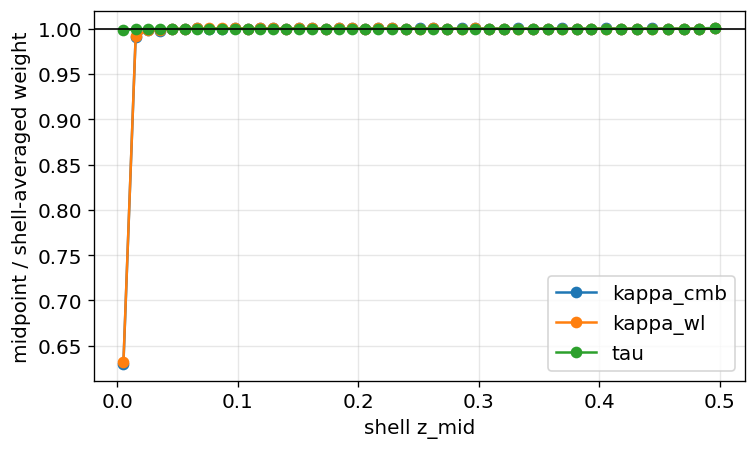

In [6]:
weights_avg = {m['step_id']: psh.compute_shell_weights(m, cls_cmb, cls_wl, mode='average', n_samples=48) for m in shell_meta}
weights_mid = {m['step_id']: psh.compute_shell_weights(m, cls_cmb, cls_wl, mode='midpoint') for m in shell_meta}
weight_rows = []
for m in shell_meta:
    step = m['step_id']
    row = {'step_id': step, 'z_mid': m['z_mid'], 'dchi_hMpc': m['dchi_hMpc']}
    for key in ['kappa_cmb', 'kappa_wl', 'tau']:
        row[f'{key}_avg'] = weights_avg[step][key]
        row[f'{key}_mid_over_avg'] = weights_mid[step][key] / weights_avg[step][key] if weights_avg[step][key] != 0 else np.nan
    weight_rows.append(row)
weights_df = pd.DataFrame(weight_rows)
display(weights_df)

fig, ax = plt.subplots(figsize=(7, 4))
for key in ['kappa_cmb', 'kappa_wl', 'tau']:
    ax.plot(weights_df['z_mid'], weights_df[f'{key}_mid_over_avg'], marker='o', label=key)
ax.axhline(1.0, color='k', lw=1)
ax.set_xlabel('shell z_mid')
ax.set_ylabel('midpoint / shell-averaged weight')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


## 6. Preview One Cached Shell

The maps below use fixed symmetric ranges for signed fields, so visual differences are not hidden by autoscaling.


preview shell: Step1014-1022 z=[ 0.000134659018104 0.010000031907325 ]


<Figure size 1440x960 with 0 Axes>

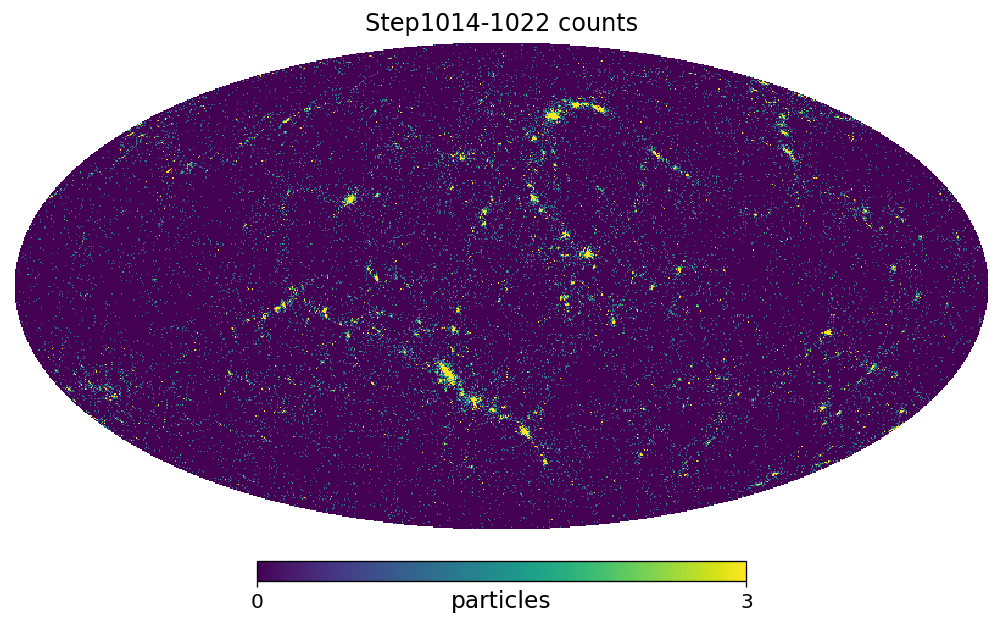

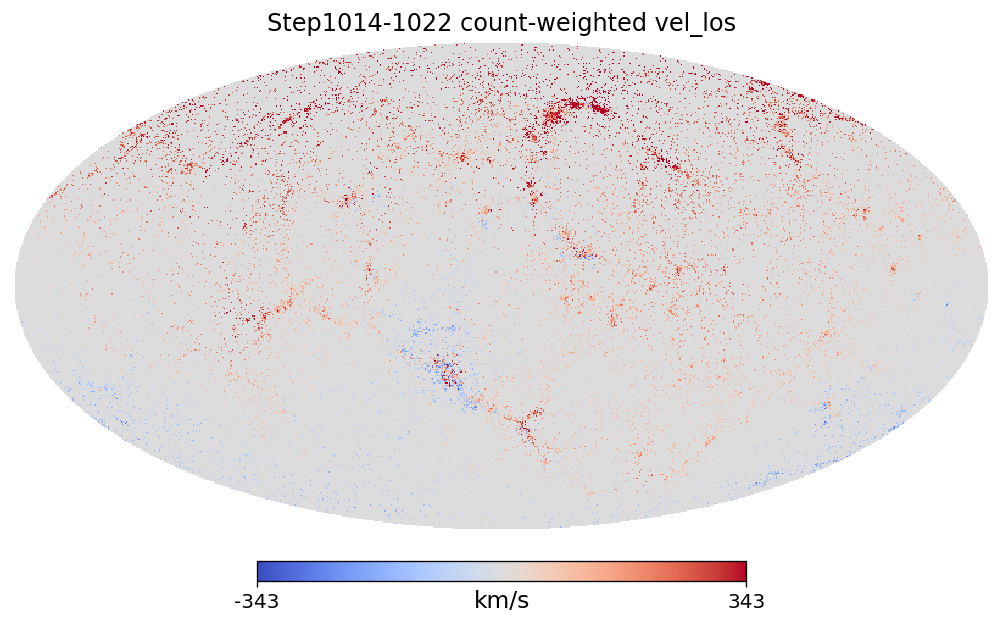

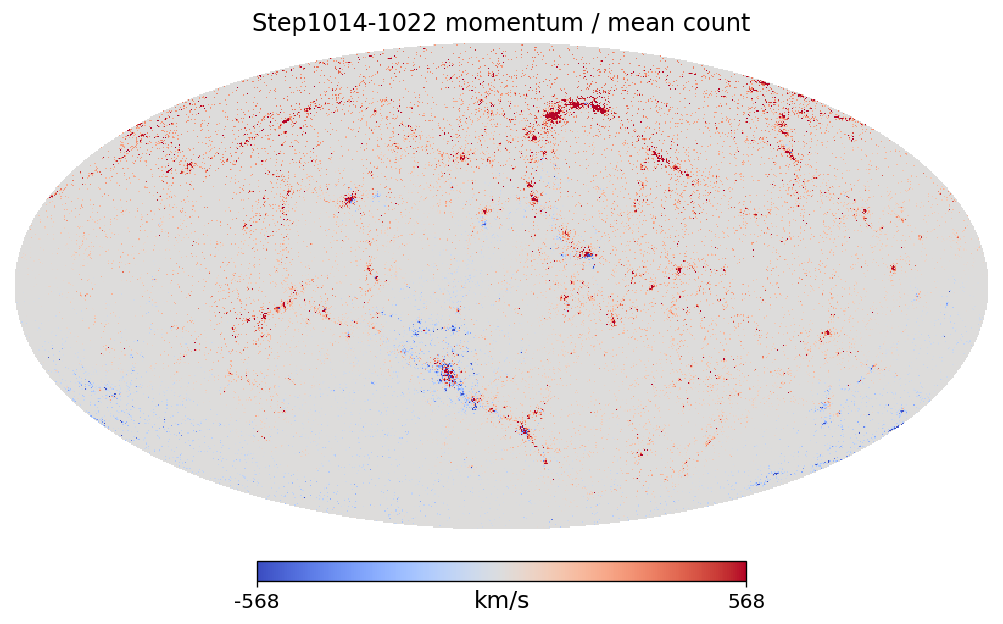

In [7]:
def moll(map_in, title, unit='', symmetric=False, quantile=99.5):
    arr = np.asarray(map_in)
    if symmetric:
        vmax = np.nanpercentile(np.abs(arr), quantile)
        vmin = -vmax
    else:
        vmin, vmax = np.nanpercentile(arr, [100 - quantile, quantile])
    hp.mollview(arr, title=title, unit=unit, min=vmin, max=vmax, cmap='coolwarm' if symmetric else 'viridis')

preview_step = shell_meta[-1]['step_id']
preview_data, preview_attrs = psh.load_downgraded_shell_cache(cache_paths[preview_step], NSIDE)
print('preview shell:', preview_step, 'z=[', preview_attrs['z_lo'], preview_attrs['z_hi'], ']')
plt.figure(figsize=(12, 8))
moll(preview_data['counts'], f'{preview_step} counts', 'particles')
moll(preview_data['vel_los'], f'{preview_step} count-weighted vel_los', 'km/s', symmetric=True)
moll(preview_data['momentum_los'] / max(np.mean(preview_data['counts']), 1.0), f'{preview_step} momentum / mean count', 'km/s', symmetric=True)
plt.show()


## 7. Selected-Halo Subtraction Templates

The point template is cheap but can make sparse pixels negative. The DMO/NFW-like template uses the same GODMAX projected DMO mass profiles as the pasted map machinery, normalizes each shell template to the selected-halo `M200c` sum, and should reduce pathological negative residuals. Velocity-weighted NFW momentum is approximated by one or more velocity bins.


In [8]:
point_templates = {}
point_rows = []
for meta in shell_meta:
    tmpl = psh.point_halo_templates_for_shell(halo_catalog, meta, NSIDE)
    point_templates[meta['step_id']] = tmpl
    point_rows.append({
        'step_id': meta['step_id'],
        'n_halos': tmpl['n_halos'],
        'template_count_sum': float(np.sum(tmpl['count_template'], dtype=np.float64)),
        'mass_sum_hMsun': tmpl['mass_sum_hMsun'],
    })
display(pd.DataFrame(point_rows))

nfw_templates = {}
if RUN_NFW_TEMPLATE:
    painter = psh.DmoTemplatePainter(CONFIG, CATALOG, NSIDE)
    print(f'Painting/loading {len(shell_meta)} DMO/NFW shell templates in bulk')
    nfw_templates = painter.paint_shell_templates(
        halo_catalog,
        shell_meta,
        CACHE_ROOT,
        overwrite=OVERWRITE_CACHE,
        velocity_bins=NFW_VELOCITY_BINS,
    )
    nfw_rows = []
    for meta in shell_meta:
        tmpl = nfw_templates[meta['step_id']]
        attrs = tmpl['attrs']
        nfw_rows.append({
            'step_id': meta['step_id'],
            'n_halos': attrs['n_halos'],
            'count_template_sum': attrs['count_template_sum'],
            'expected_count_sum': attrs['expected_count_sum'],
            'velocity_bins': attrs['velocity_bins'],
            'bulk_template': bool(attrs.get('bulk_template', False)),
        })
    display(pd.DataFrame(nfw_rows))
    del painter
    gc.collect()
else:
    print('RUN_NFW_TEMPLATE=False; skipping DMO/NFW selected-halo templates.')


,step_id,n_halos,template_count_sum,mass_sum_hMsun
0,Step0689-0695,6398,279419667.0,1.121313e+18
1,Step0696-0701,6635,288157636.0,1.156379e+18
2,Step0702-0707,6590,291348352.0,1.169183e+18
3,Step0708-0714,7408,320104553.0,1.284582e+18
4,Step0715-0721,6698,294819543.0,1.183113e+18
5,Step0722-0727,6083,270059669.0,1.083752e+18
6,Step0728-0734,6679,297300226.0,1.193068e+18
7,Step0735-0740,5640,249322240.0,1.000532e+18
8,Step0741-0747,6456,289545519.0,1.161948e+18
9,Step0748-0753,5199,231823030.0,9.303077e+17


Painting/loading 44 DMO/NFW shell templates in bulk


,step_id,n_halos,count_template_sum,expected_count_sum,velocity_bins,bulk_template
0,Step0689-0695,6398,2.794197e+08,279419667.0,4,True
1,Step0696-0701,6635,2.881576e+08,288157636.0,4,True
2,Step0702-0707,6590,2.913484e+08,291348352.0,4,True
3,Step0708-0714,7408,3.201046e+08,320104553.0,4,True
4,Step0715-0721,6698,2.948195e+08,294819543.0,4,True
5,Step0722-0727,6083,2.700597e+08,270059669.0,4,True
6,Step0728-0734,6679,2.973002e+08,297300226.0,4,True
7,Step0735-0740,5640,2.493222e+08,249322240.0,4,True
8,Step0741-0747,6456,2.895455e+08,289545519.0,4,True
9,Step0748-0753,5199,2.318230e+08,231823030.0,4,True


## 8. Build Shell Field Maps

All residual fields are normalized in full-matter units. For example, after selected-halo subtraction the residual density field is `(counts - template - mean_residual) / mean_total`, not `(counts - template) / mean_residual - 1`. This matters because kappa theory is normalized to the total matter density.


In [9]:
total_shell_maps, total_diag = psh.build_shell_field_maps(shell_meta, cache_paths, weights_avg, NSIDE)
point_residual_maps, point_diag = psh.build_shell_field_maps(
    shell_meta, cache_paths, weights_avg, NSIDE, templates_by_step=point_templates, clip_negative_counts=False
)
point_clipped_maps, point_clip_diag = psh.build_shell_field_maps(
    shell_meta, cache_paths, weights_avg, NSIDE, templates_by_step=point_templates, clip_negative_counts=True
)

nfw_residual_maps, nfw_diag = None, []
if RUN_NFW_TEMPLATE and nfw_templates:
    nfw_residual_maps, nfw_diag = psh.build_shell_field_maps(
        shell_meta, cache_paths, weights_avg, NSIDE, templates_by_step=nfw_templates, clip_negative_counts=False
    )

summary_diag = []
for label, rows in [('total', total_diag), ('point', point_diag), ('point_clipped', point_clip_diag), ('nfw', nfw_diag)]:
    for row in rows:
        summary_diag.append({'model': label, **row})
diag_df = pd.DataFrame(summary_diag)
display(diag_df[['model', 'step_id', 'mean_total_counts', 'mean_source_counts', 'source_mass_fraction', 'frac_negative_source_pix', 'min_source_counts']])


,model,step_id,mean_total_counts,mean_source_counts,source_mass_fraction,frac_negative_source_pix,min_source_counts
0,total,Step0689-0695,1274.151001,1274.151001,1.000000,0.000000,107.000000
1,total,Step0696-0701,1002.792419,1002.792419,1.000000,0.000000,74.000000
2,total,Step0702-0707,951.977600,951.977600,1.000000,0.000000,72.000000
3,total,Step0708-0714,1066.938599,1066.938599,1.000000,0.000000,86.000000
4,total,Step0715-0721,931.814392,931.814392,1.000000,0.000000,63.000000
...,...,...,...,...,...,...,...
171,nfw,Step0978-0986,13.512867,12.622611,0.934118,0.003662,-859.538086
172,nfw,Step0987-0995,7.886597,7.359598,0.933178,0.004022,-1218.218994
173,nfw,Step0996-1004,4.011794,3.794233,0.945770,0.004042,-457.025879
174,nfw,Step1005-1013,1.370017,1.316850,0.961193,0.002779,-89.736832


## 9. Residual Map Preview

These panels make the double-counting issue visible. The total shell map is an upper bound if added to pasted maps; selected-halo subtraction should lower the amplitude and avoid obvious artifacts.


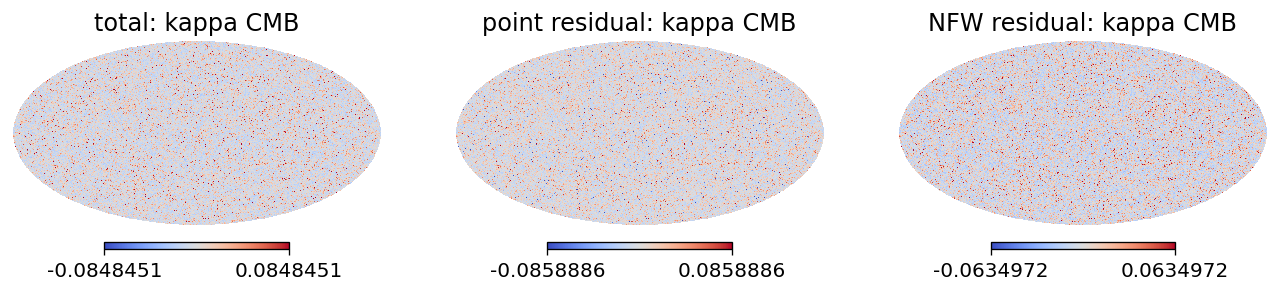

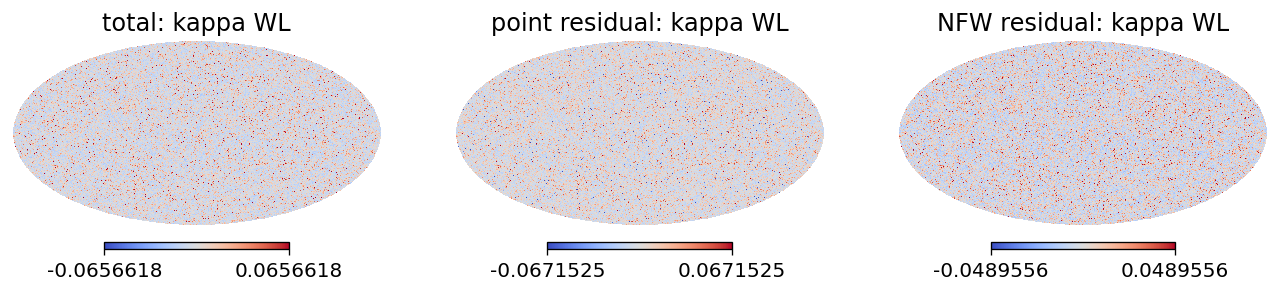

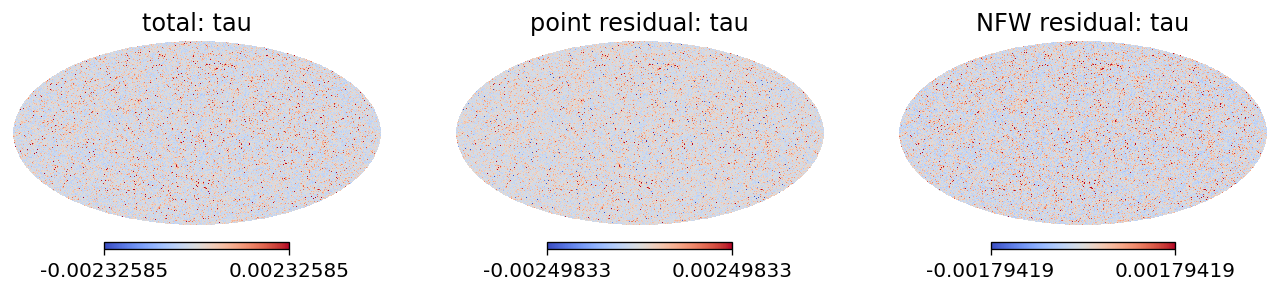

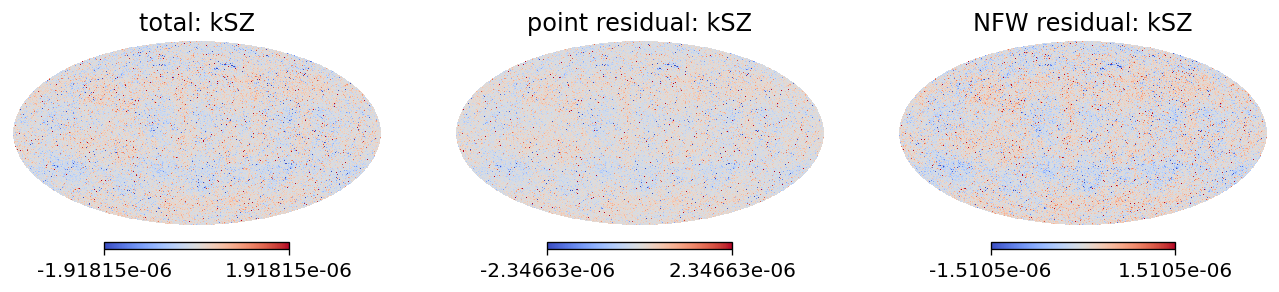

In [10]:
preview_fields = [
    ('map_kappa_cmb', 'kappa CMB'),
    ('map_kappa_wl', 'kappa WL'),
    ('map_tau', 'tau'),
    ('map_ksz', 'kSZ'),
]
preview_models = [('total', total_shell_maps), ('point residual', point_residual_maps)]
if nfw_residual_maps is not None:
    preview_models.append(('NFW residual', nfw_residual_maps))

for field, label in preview_fields:
    ncols = len(preview_models)
    fig = plt.figure(figsize=(4.5 * ncols, 3.5))
    for i, (model_name, model_maps) in enumerate(preview_models, 1):
        plt.subplot(1, ncols, i)
        hp.mollview(model_maps[field], title=f'{model_name}: {label}', hold=True, cmap='coolwarm', min=-np.nanpercentile(np.abs(model_maps[field]), 99.5), max=np.nanpercentile(np.abs(model_maps[field]), 99.5))
    plt.show()


## 10. Measure Variants

The variants are measured sequentially to keep memory bounded. Additive total shells are an upper bound. The physically useful candidates are selected-halo residuals and low-ell total-shell replacement.


In [11]:
def measure_variant(name, maps_here, store=None):
    print('measuring', name)
    cls = aph.measure_basic_cls(maps_here, galaxies, NSIDE, z_range=z_range)
    store[name] = cls
    return cls

cls_by_variant = {}
measure_variant('pasted_only', maps_pasted, cls_by_variant)
measure_variant('pasted_plus_total_upper_bound', psh.add_field_maps(maps_pasted, total_shell_maps), cls_by_variant)
measure_variant('pasted_plus_point_residual', psh.add_field_maps(maps_pasted, point_residual_maps), cls_by_variant)
measure_variant('pasted_plus_point_clipped', psh.add_field_maps(maps_pasted, point_clipped_maps), cls_by_variant)
if nfw_residual_maps is not None:
    measure_variant('pasted_plus_nfw_residual', psh.add_field_maps(maps_pasted, nfw_residual_maps), cls_by_variant)

for ell_cut in TAPER_ELLS:
    blended = psh.harmonic_blend_maps(maps_pasted, total_shell_maps, NSIDE, ell_cut)
    measure_variant(f'lowell_total_replace_L{ell_cut}', blended, cls_by_variant)
    del blended
    gc.collect()

print('measured variants:', list(cls_by_variant))


measuring pasted_only
measuring pasted_plus_total_upper_bound
measuring pasted_plus_point_residual
measuring pasted_plus_point_clipped
measuring pasted_plus_nfw_residual


/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/xDESI/abacus_particle_shell_helpers.py:575: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  blended = hp.alm2map(base_alm + delta_alm, nside, lmax=lmax, verbose=False)


measuring lowell_total_replace_L128
measuring lowell_total_replace_L256
measuring lowell_total_replace_L512
measuring lowell_total_replace_L768
measured variants: ['pasted_only', 'pasted_plus_total_upper_bound', 'pasted_plus_point_residual', 'pasted_plus_point_clipped', 'pasted_plus_nfw_residual', 'lowell_total_replace_L128', 'lowell_total_replace_L256', 'lowell_total_replace_L512', 'lowell_total_replace_L768']


## 11. Amplitude-Calibrated Residual Diagnostics

This is not the preferred production correction. It asks how much of a residual map is needed to match theory in a training ell range. For kappa, a good physical residual should have `A_kappa` close to 1. For tau, a non-unity or scale-dependent amplitude is evidence for an electron-bias mismatch.


In [12]:
residual_cls = {
    'total_shell': aph.measure_basic_cls(psh.complete_maps_for_measurement(total_shell_maps, NSIDE), galaxies, NSIDE, z_range=z_range),
    'point_residual': aph.measure_basic_cls(psh.complete_maps_for_measurement(point_residual_maps, NSIDE), galaxies, NSIDE, z_range=z_range),
}
if nfw_residual_maps is not None:
    residual_cls['nfw_residual'] = aph.measure_basic_cls(psh.complete_maps_for_measurement(nfw_residual_maps, NSIDE), galaxies, NSIDE, z_range=z_range)

amp_rows = []
base = cls_by_variant['pasted_only']
for res_name, res_cls in residual_cls.items():
    ell = base['ell']
    for field in ['gkappa_cmb', 'gkappa_wl', 'gtau']:
        th = np.interp(ell, ell_th, theory[field], left=np.nan, right=np.nan)
        fit = psh.fit_residual_amplitude(ell, base[field], res_cls[field], th, TRAIN_ELL_RANGE)
        amp_rows.append({'residual': res_name, 'field': field, **fit})
amp_df = pd.DataFrame(amp_rows)
display(amp_df)


,residual,field,amplitude,n_train,rms_frac_after
0,total_shell,gkappa_cmb,0.521953,291,0.297358
1,total_shell,gkappa_wl,0.515203,291,0.301134
2,total_shell,gtau,0.496281,291,0.323954
3,point_residual,gkappa_cmb,0.757264,291,0.205208
4,point_residual,gkappa_wl,0.749326,291,0.209104
5,point_residual,gtau,0.710722,291,0.248894
6,nfw_residual,gkappa_cmb,0.750463,291,0.215653
7,nfw_residual,gkappa_wl,0.742523,291,0.219747
8,nfw_residual,gtau,0.718695,291,0.252505


## 12. Cross-Spectrum Plots

The ratio panels are the main decision plots.  They now use the recommended no-response `gg` theory setting controlled by `THEORY_GG_TRANSITION_MODEL`.  `gy`, `gkappa_cmb`, `gkappa_wl`, and `gtau` are compared to GODMAX theory; kSZ has no theory curve and is shown only to check sign, finiteness, and morphology of the LOS-momentum residual.


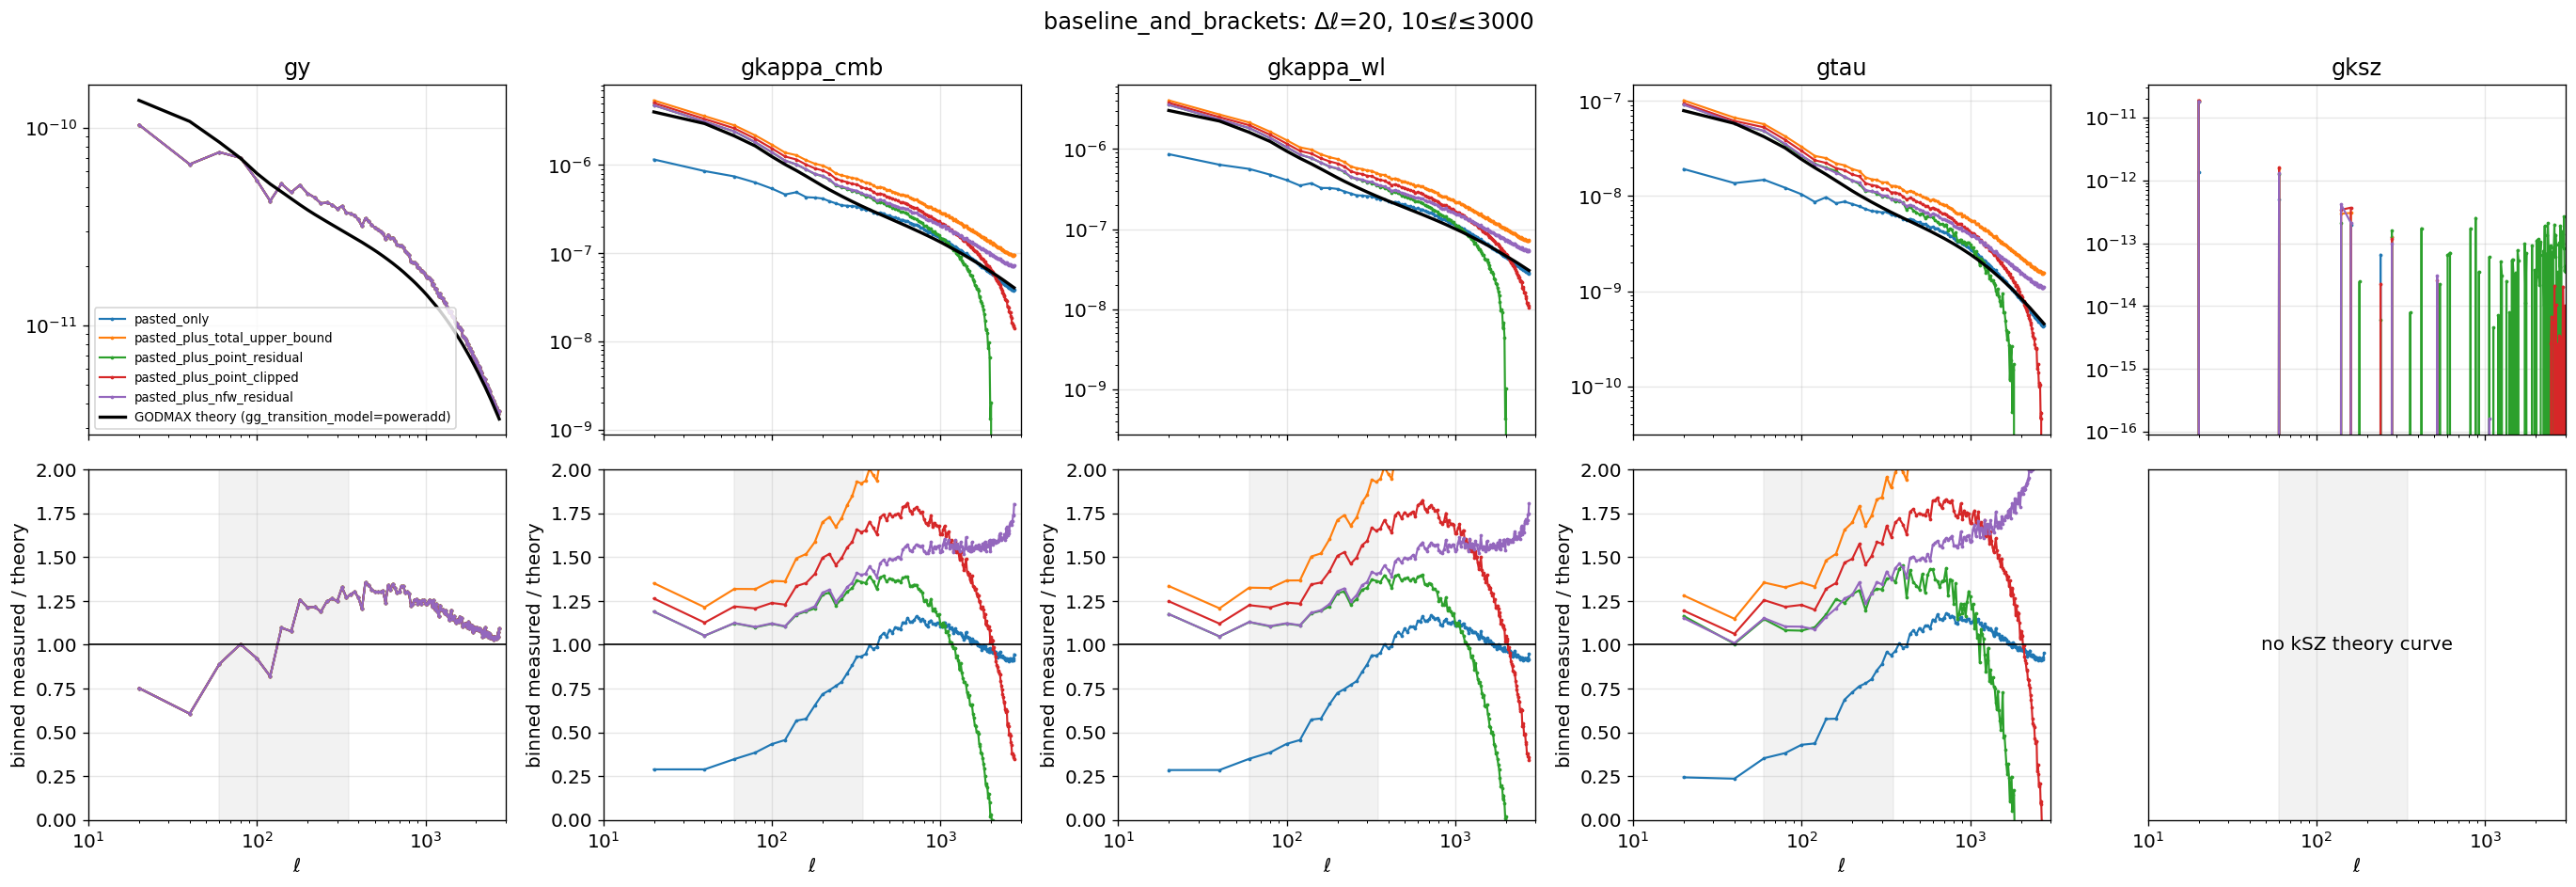

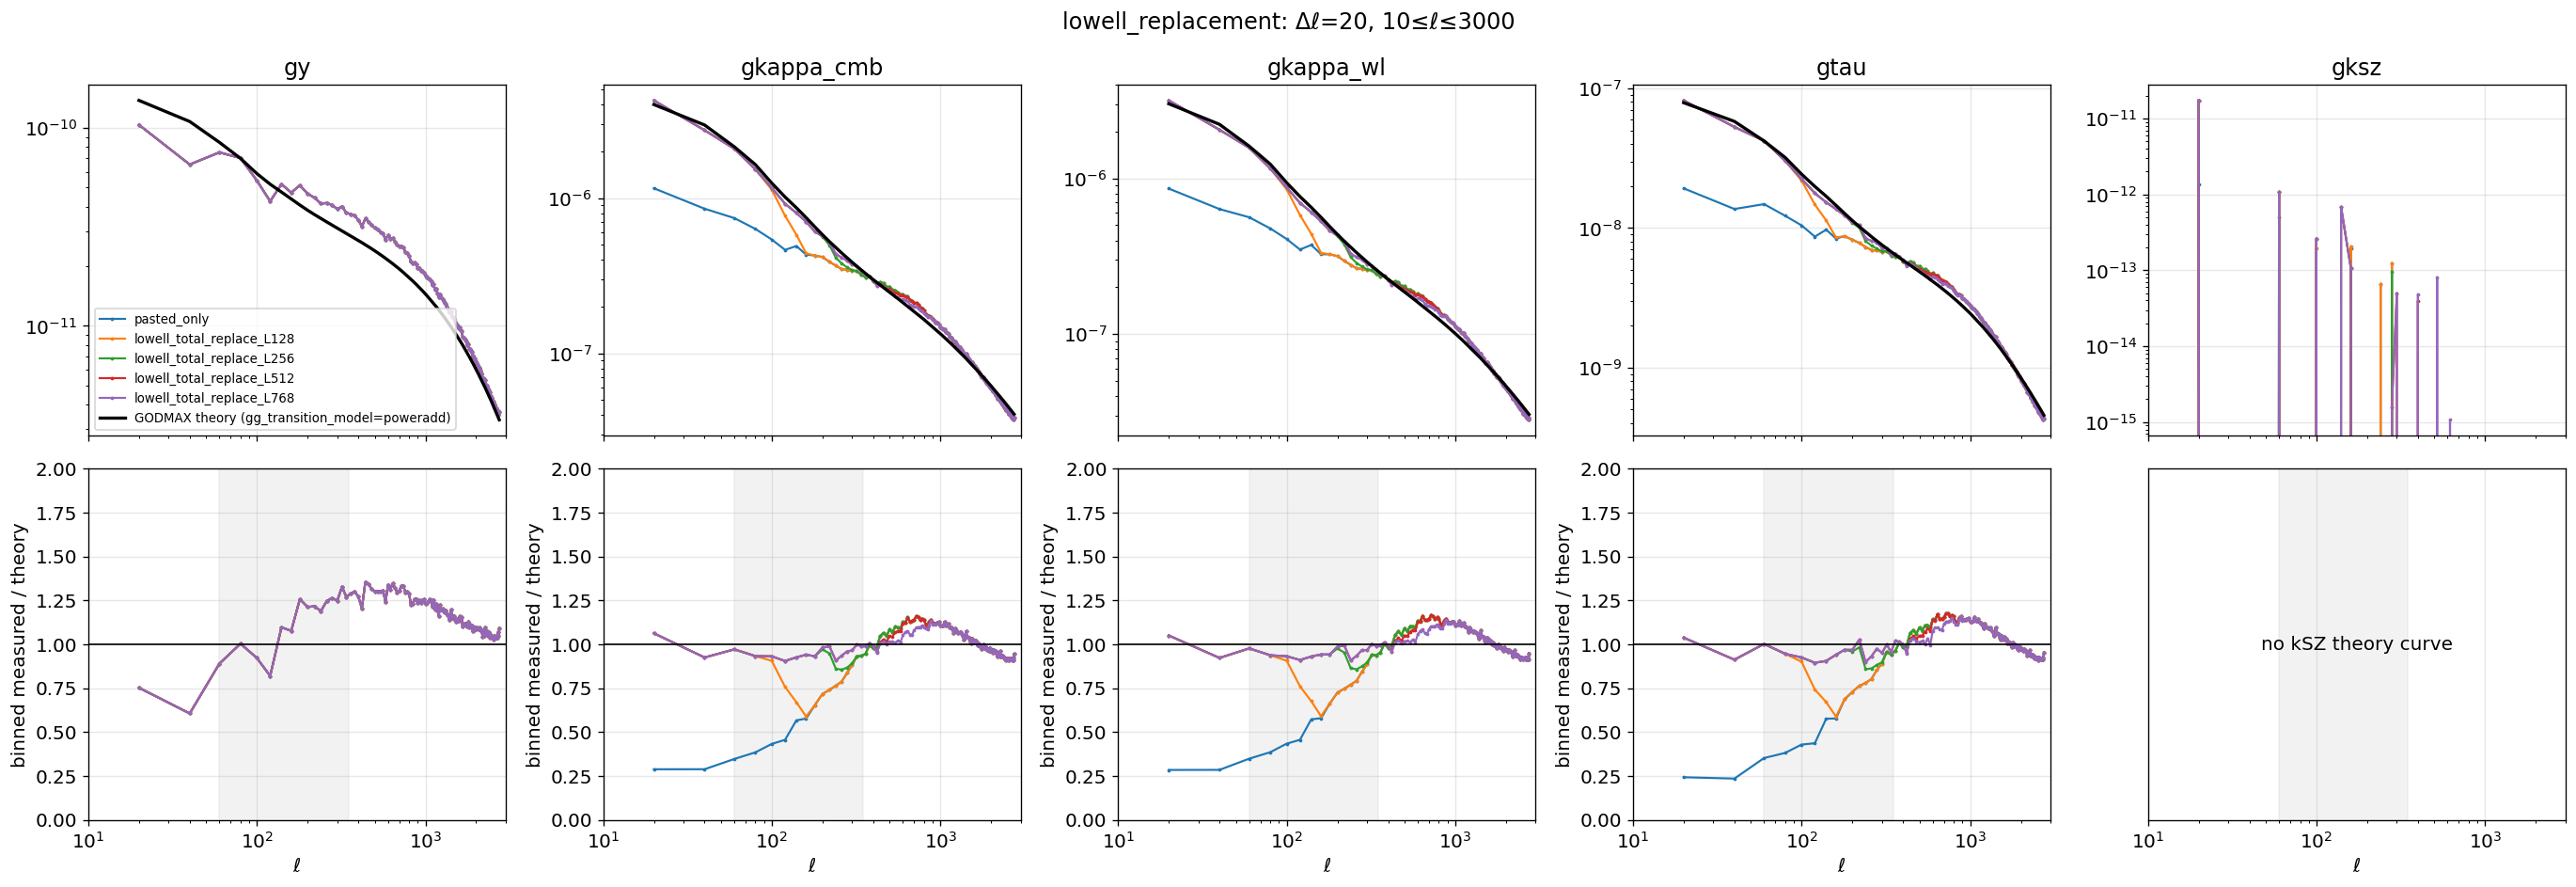

In [13]:
plot_groups = {
    'baseline_and_brackets': ['pasted_only', 'pasted_plus_total_upper_bound', 'pasted_plus_point_residual', 'pasted_plus_point_clipped'] + (['pasted_plus_nfw_residual'] if 'pasted_plus_nfw_residual' in cls_by_variant else []),
    'lowell_replacement': ['pasted_only'] + [f'lowell_total_replace_L{ell}' for ell in TAPER_ELLS if f'lowell_total_replace_L{ell}' in cls_by_variant],
}
colors = plt.cm.tab10(np.linspace(0, 1, 10))

def binned_curve(ell, values):
    return psh.bin_spectrum(ell, values, ell_min=ELL_PLOT_MIN, ell_max=ELL_PLOT_MAX, delta_ell=DELTA_ELL)

def binned_curve_pair(ell, measured, reference):
    return psh.bin_spectrum_pair(ell, measured, reference, ell_min=ELL_PLOT_MIN, ell_max=ELL_PLOT_MAX, delta_ell=DELTA_ELL)

def plot_group(group_name, names):
    fields = ['gy', 'gkappa_cmb', 'gkappa_wl', 'gtau', 'gksz']
    fig, axes = plt.subplots(2, len(fields), figsize=(23, 8), sharex='col')
    for j, field in enumerate(fields):
        ax = axes[0, j]
        rax = axes[1, j]
        theory_bin = None
        for i, name in enumerate(names):
            cls = cls_by_variant[name]
            ell = cls['ell']
            color = colors[i % len(colors)]
            if field in theory:
                th_on_measured_ell = np.interp(ell, ell_th, theory[field], left=np.nan, right=np.nan)
                paired_bin = binned_curve_pair(ell, cls[field], th_on_measured_ell)
                if len(paired_bin['ell']) == 0:
                    continue
                ax.plot(paired_bin['ell'], paired_bin['value_a'], lw=1.3, marker='.', ms=2.5, label=name, color=color)
                rax.plot(paired_bin['ell'], paired_bin['ratio'], lw=1.3, marker='.', ms=2.5, color=color)
                if theory_bin is None:
                    theory_bin = {'ell': paired_bin['ell'], 'value': paired_bin['value_b']}
            else:
                measured_bin = binned_curve(ell, cls[field])
                ax.plot(measured_bin['ell'], measured_bin['value'], lw=1.3, marker='.', ms=2.5, label=name, color=color)
        if field in theory:
            if theory_bin is not None:
                ax.plot(theory_bin['ell'], theory_bin['value'], color='k', lw=2.0, label=THEORY_LABEL)
            rax.axhline(1.0, color='k', lw=1.0)
            rax.set_ylim(0.0, 2.0)
            rax.set_ylabel('binned measured / theory')
        else:
            rax.text(0.5, 0.5, 'no kSZ theory curve', transform=rax.transAxes, ha='center', va='center')
            rax.set_yticks([])
        ax.set_title(field)
        ax.set_xlim(ELL_PLOT_MIN, ELL_PLOT_MAX)
        rax.set_xlim(ELL_PLOT_MIN, ELL_PLOT_MAX)
        ax.set_xscale('log')
        # ax.set_yscale('symlog', linthresh=1e-12)
        ax.set_yscale('log')        

        ax.grid(alpha=0.3)
        rax.set_xscale('log')
        rax.grid(alpha=0.3)
        rax.axvspan(TRAIN_ELL_RANGE[0], TRAIN_ELL_RANGE[1], color='0.8', alpha=0.25)
        rax.set_xlabel(r'$\ell$')
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f'{group_name}: Δℓ={DELTA_ELL}, {ELL_PLOT_MIN}≤ℓ≤{ELL_PLOT_MAX}')
    fig.tight_layout()
    plt.show()

for group_name, names in plot_groups.items():
    plot_group(group_name, names)


## 13. Galaxy Auto-Spectrum Context

The residual maps do not change the galaxy catalog. This plot keeps both galaxy auto curves visible: with shot noise and with shot noise subtracted.  The theory curve uses the notebook-level `THEORY_GG_TRANSITION_MODEL` setting; the recommended value is `poweradd`, which removes the response suppression that was driving much of the small-scale `gg` discrepancy.


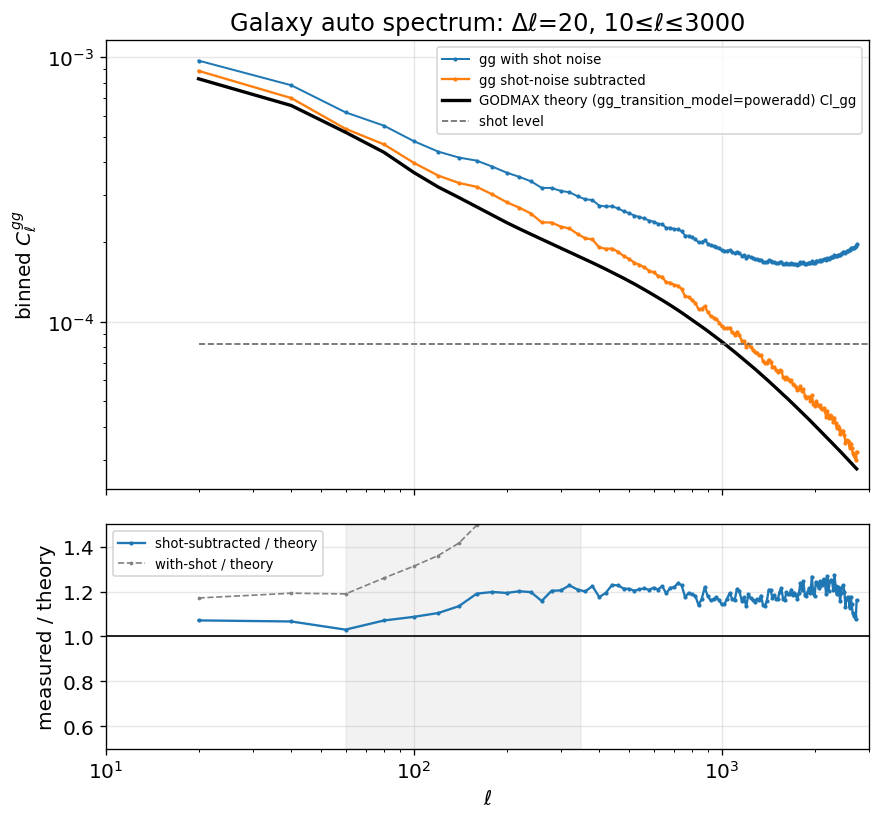

Ngal: 152180 shot_gg: 8.257570386620562e-05


In [16]:
base_cls = cls_by_variant['pasted_only']
ell = base_cls['ell']

def binned_curve_local(ell, values):
    return psh.bin_spectrum(ell, values, ell_min=ELL_PLOT_MIN, ell_max=ELL_PLOT_MAX, delta_ell=DELTA_ELL)

def binned_curve_pair_local(ell, measured, reference):
    return psh.bin_spectrum_pair(ell, measured, reference, ell_min=ELL_PLOT_MIN, ell_max=ELL_PLOT_MAX, delta_ell=DELTA_ELL)

# GODMAX Cl_gg is the clustering-only galaxy auto spectrum. The measured curve
# that should be compared directly is therefore gg_without_shot.
theory_gg = np.asarray(theory.get('gg', cls_cmb.Cl_gal_gal_tot_mat[:, compare_bin, compare_bin]))
theory['gg'] = theory_gg
th_on_measured_ell = np.interp(ell, ell_th, theory_gg, left=np.nan, right=np.nan)

gg_with = binned_curve_pair_local(ell, base_cls['gg_with_shot'], th_on_measured_ell)
gg_without = binned_curve_pair_local(ell, base_cls['gg_without_shot'], th_on_measured_ell)
shot_bin = binned_curve_local(ell, np.full_like(ell, base_cls['shot_gg'], dtype=np.float64))

fig, axes = plt.subplots(2, 1, figsize=(7.5, 7.0), sharex=True, gridspec_kw={'height_ratios': [2.0, 1.0]})
ax, rax = axes
ax.plot(gg_with['ell'], gg_with['value_a'], marker='.', ms=3, lw=1.2, label='gg with shot noise')
ax.plot(gg_without['ell'], gg_without['value_a'], marker='.', ms=3, lw=1.4, label='gg shot-noise subtracted')
ax.plot(gg_without['ell'], gg_without['value_b'], color='k', lw=2.0, label=THEORY_LABEL + ' Cl_gg')
ax.plot(shot_bin['ell'], shot_bin['value'], color='0.4', ls='--', lw=1.0, label='shot level')

rax.plot(gg_without['ell'], gg_without['ratio'], marker='.', ms=3, lw=1.4, label='shot-subtracted / theory')
rax.plot(gg_with['ell'], gg_with['ratio'], marker='.', ms=2.5, lw=1.0, ls='--', color='0.5', label='with-shot / theory')
rax.axhline(1.0, color='k', lw=1.0)
rax.axvspan(TRAIN_ELL_RANGE[0], TRAIN_ELL_RANGE[1], color='0.8', alpha=0.25)

ax.set_xlim(ELL_PLOT_MIN, ELL_PLOT_MAX)
ax.set_xscale('log')
# ax.set_yscale('symlog', linthresh=1e-9)
ax.set_yscale('log')
ax.set_ylabel(r'binned $C_\ell^{gg}$')
ax.set_title(f'Galaxy auto spectrum: Δℓ={DELTA_ELL}, {ELL_PLOT_MIN}≤ℓ≤{ELL_PLOT_MAX}')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

rax.set_xscale('log')
rax.set_xlabel(r'$\ell$')
rax.set_ylabel('measured / theory')
rax.grid(alpha=0.3)
rax.set_ylim(0.5, 1.5)
rax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print('Ngal:', base_cls['n_gal'], 'shot_gg:', base_cls['shot_gg'])


## 14. Decision Summary

Use the diagnostics below to choose a production correction:

- The theory setting is now explicit. The recommended comparison is `THEORY_GG_TRANSITION_MODEL='poweradd'`, not response-suppressed `Pgg`.
- `pasted_plus_total_upper_bound` should usually overcorrect because it double-counts selected halos.
- `pasted_plus_point_residual` is useful only if negative residual pixels are rare.
- `pasted_plus_nfw_residual` is the preferred additive residual if it reduces negative pixels and has `A_kappa ~ 1`.
- `lowell_total_replace_L*` is the preferred large-scale-safe strategy if it brings kappa ratios toward unity while leaving high ell unchanged.
- For tau, a stable amplitude offset is an electron-bias calibration issue; a scale-dependent offset means the matter-shell residual is not enough.
- kSZ should be finite and velocity-like, but it has no theory acceptance criterion here.
- Existing pasted maps were generated from the current catalog file. Regenerate the preprocessed catalog and pasted maps before final production if you want the comoving-`R200c` map-support fix included.


In [15]:
ratio_rows = []
for name, cls in cls_by_variant.items():
    ell = cls['ell']
    valid = (ell >= TRAIN_ELL_RANGE[0]) & (ell <= TRAIN_ELL_RANGE[1])
    row = {'variant': name}
    for field in ['gy', 'gkappa_cmb', 'gkappa_wl', 'gtau']:
        th = np.interp(ell, ell_th, theory[field], left=np.nan, right=np.nan)
        ratio = cls[field] / th
        mask = valid & np.isfinite(ratio)
        row[f'{field}_ratio_mean'] = float(np.nanmean(ratio[mask])) if np.any(mask) else np.nan
        row[f'{field}_ratio_std'] = float(np.nanstd(ratio[mask])) if np.any(mask) else np.nan
    row['gksz_rms_train'] = float(np.sqrt(np.nanmean(cls['gksz'][valid] ** 2))) if np.any(valid) else np.nan
    ratio_rows.append(row)
summary = pd.DataFrame(ratio_rows)
display(summary)

if 'model' in diag_df:
    neg_summary = diag_df.groupby('model')[['frac_negative_source_pix', 'source_mass_fraction']].mean()
    display(neg_summary)


,variant,gy_ratio_mean,gy_ratio_std,gkappa_cmb_ratio_mean,gkappa_cmb_ratio_std,gkappa_wl_ratio_mean,gkappa_wl_ratio_std,gtau_ratio_mean,gtau_ratio_std,gksz_rms_train
0,pasted_only,1.14142,0.32777,0.680404,0.199644,0.685136,0.203256,0.689836,0.222716,2.154257e-12
1,pasted_plus_total_upper_bound,1.14142,0.32777,1.629771,0.289123,1.638169,0.295857,1.636606,0.363340,4.570116e-12
2,pasted_plus_point_residual,1.14142,0.32777,1.232266,0.188717,1.237775,0.193116,1.237599,0.271428,3.172917e-12
3,pasted_plus_point_clipped,1.14142,0.32777,1.433413,0.239903,1.441034,0.246853,1.437796,0.318835,4.417349e-12
4,pasted_plus_nfw_residual,1.14142,0.32777,1.248768,0.196495,1.254392,0.201261,1.249493,0.260196,3.366372e-12
5,lowell_total_replace_L128,1.14142,0.32777,0.798547,0.150189,0.803679,0.153150,0.806778,0.183712,2.740521e-12
6,lowell_total_replace_L256,1.14142,0.32777,0.917245,0.134198,0.921858,0.138057,0.921898,0.194447,2.821888e-12
7,lowell_total_replace_L512,1.14142,0.32777,0.949367,0.144561,0.953033,0.147975,0.946769,0.210343,2.841673e-12
8,lowell_total_replace_L768,1.14142,0.32777,0.949367,0.144561,0.953033,0.147975,0.946769,0.210343,2.841673e-12


,frac_negative_source_pix,source_mass_fraction
model,,
nfw,0.001653,0.960765
point,0.000246,0.960765
point_clipped,0.000000,0.987267
total,0.000000,1.000000
